# Stage 1 — Channel Data Generation (TR 38.843 configs)

Generates **train/test CSI datasets** and **realistic PMI CSI-report data** for each
channel configuration, **verifies** each generated channel against the 3GPP TR 38.901
CDL tables, and saves everything to `data/<channel_label>/` via the `csi` IO contract.

Per config the following files are written:

| File | Contents |
|------|----------|
| `train.npz` | `H` complex64 `(n_train, n_sub, n_tx)` |
| `test.npz`  | `H` complex64 `(n_test,  n_sub, n_tx)` |
| `reports.npz` | dominant eigenvectors + Type I/II PMI codebook metrics (under **noisy CSI estimation**) |
| `config.json` | `ChannelConfig` provenance record |
| `meta.json`   | free-form provenance dict |

Channel models generated: **CDL-A** (NLOS, rich), **CDL-C** (NLOS), **CDL-E** (LOS) via
Sionna TR 38.901, plus a **synthetic** beam-like reference. Each Sionna channel is checked
against TR 38.901 §7.7.1 (per-cluster delay/power/angles) before it is trusted.


In [1]:
import os
# Single-threaded BLAS so the process pool below scales cleanly across cores.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
           'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, '1')

import sys
_SRC = os.path.abspath('../src')
sys.path.insert(0, _SRC)
# Spawned workers inherit PYTHONPATH (but NOT sys.path), so put src there too
# — this is what lets fresh processes `import csi`.
os.environ['PYTHONPATH'] = _SRC + os.pathsep + os.environ.get('PYTHONPATH', '')

import numpy as np
import csi
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# ── multiprocessing helper for the per-sample codebook loops ────────────────
N_JOBS = max(1, (os.cpu_count() or 4) - 1)
_SPAWN = _mp.get_context('spawn')         # robust under nbclient on macOS
_EXEC = None

def _pool(n):
    global _EXEC
    if _EXEC is None:
        _EXEC = ProcessPoolExecutor(max_workers=n, mp_context=_SPAWN)
    return _EXEC

def pmap(func, X, n_jobs=N_JOBS, **kw):
    '''Apply a csi codebook *func* over rows of X across processes -> (W_hat, bits).
    func(X_chunk, **kw) must return (array, bits); bits is identical per chunk.'''
    if n_jobs <= 1 or len(X) < 2 * n_jobs:
        return func(X, **kw)
    chunks = np.array_split(X, n_jobs)
    res = list(_pool(n_jobs).map(partial(func, **kw), chunks))
    return np.concatenate([r[0] for r in res], axis=0), res[0][1]

import atexit
atexit.register(lambda: _EXEC.shutdown(wait=False) if _EXEC is not None else None)

print('csi loaded from:', _SRC, '| multiprocessing N_JOBS =', N_JOBS)


csi loaded from: /Users/hjl/Documents/Github/csi_report/src | multiprocessing N_JOBS = 15


## Channel configurations

Each dataset is fully specified by a `csi.ChannelConfig`. Sionna configs map to a
TR 38.901 CDL profile via `cfg.sionna_kwargs()`; the synthetic config uses the
pure-NumPy `csi.generate_csi_dataset`.

New TR-38.843 knobs used here:
- **`snr_db` / `pathloss_db`** — the CSI is estimated under AWGN at the *effective*
  SNR `snr_db - pathloss_db` (`csi.add_awgn`); PMI is reported from the **noisy**
  estimate but scored against the **true** precoder, so estimation error is visible.
- **`ue_speed` / `num_time_steps`** — Doppler mobility (demonstrated at the end).


In [2]:
# Number of delay taps kept in the angular-delay representation.
N_DELAY = 32

# ---------------------------------------------------------------------------
# TR 38.843 channel configurations (CDL-A/C/E + synthetic).
# Shared grid: 3.5 GHz / 30 kHz / 51 RB = 612 subcarriers / 32 TX / dual-pol.
# 25000 train + 5000 test, UE speed 0.5 m/s, CSI estimated at 20 dB SNR.
# delay_spread is per-profile (in SECONDS): 100 ns = 100e-9, 300 ns = 300e-9.
# ---------------------------------------------------------------------------
def _cdl(model, label, delay_spread, ue_speed=0.5):
    return csi.ChannelConfig(
        channel_model=model, data_source='sionna',
        carrier_frequency=3.5e9, bandwidth=20e6, scs=30e3, rb=51, nfu=612,
        gnb_tx=32, ue_rx=1, max_rank=1, dual_pol=True,
        delay_spread=delay_spread, ue_speed=ue_speed,
        snr_db=20.0, pathloss_db=0.0,
        n_orient=16, n_train=25000, n_test=5000, seed=0,
        channel_label=label,
    )

CONFIGS = [
    _cdl('CDL-A', 'cdla_3p5ghz', 100e-9),   # NLOS, rich multipath
    _cdl('CDL-C', 'cdlc_3p5ghz', 300e-9),   # NLOS, moderate
    _cdl('CDL-E', 'cdle_3p5ghz', 100e-9),   # LOS, sparse
    # MIXED CDL-A/C/E — equal blend, shuffled, for cross-profile generalization
    # (a TR 38.843 generalization scenario: one model robust across channels).
    csi.ChannelConfig(
        channel_model='CDL-MIX', data_source='mixed', mix_models='CDL-A,CDL-C,CDL-E',
        carrier_frequency=3.5e9, bandwidth=20e6, scs=30e3, rb=51, nfu=612,
        gnb_tx=32, ue_rx=1, max_rank=1, dual_pol=True, ue_speed=0.5,
        snr_db=20.0, pathloss_db=0.0,
        n_orient=16, n_train=25000, n_test=5000, seed=0, channel_label='mixed_cdl_ace',
    ),
    # Synthetic beam-like — pure-NumPy DFT-sparse model
    csi.ChannelConfig(
        channel_model='synthetic', data_source='synthetic',
        carrier_frequency=3.5e9, bandwidth=20e6, scs=30e3, rb=51, nfu=612,
        gnb_tx=32, ue_rx=1, max_rank=1, snr_db=20.0,
        n_train=25000, n_test=5000, seed=1, channel_label='synthetic_beam',
    ),
]

for cfg in CONFIGS:
    print(f'  {cfg.to_dirname():16s}  model={cfg.channel_model:9s} '
          f'n_sub={cfg.n_sub()} n_tx={cfg.gnb_tx} '
          f'DS={cfg.delay_spread*1e9:.0f}ns SNR={cfg.effective_snr_db():.0f}dB '
          f'n_train={cfg.n_train} n_test={cfg.n_test}')


  cdla_3p5ghz       model=CDL-A     n_sub=612 n_tx=32 DS=100ns SNR=20dB n_train=25000 n_test=5000
  cdlc_3p5ghz       model=CDL-C     n_sub=612 n_tx=32 DS=300ns SNR=20dB n_train=25000 n_test=5000
  cdle_3p5ghz       model=CDL-E     n_sub=612 n_tx=32 DS=100ns SNR=20dB n_train=25000 n_test=5000
  mixed_cdl_ace     model=CDL-MIX   n_sub=612 n_tx=32 DS=300ns SNR=20dB n_train=25000 n_test=5000
  synthetic_beam    model=synthetic n_sub=612 n_tx=32 DS=300ns SNR=20dB n_train=25000 n_test=5000


In [3]:
def build_reports(H_test, n_tx, n_delay, snr_db, seed=0, dual_pol=False):
    # Per-test-sample PMI metrics under NOISY CSI estimation.
    #
    # Realistic chain: the UE estimates a noisy channel Hhat = H + AWGN at
    # `snr_db`, derives its precoder from Hhat, and reports a PMI. We score every
    # reported precoder against the TRUE eigenvector of the clean H, so the SGCS
    # reflects estimation error AND codebook quantization (not quantization alone).
    rng = np.random.default_rng(1234 + seed)
    reports = {}

    # ── ground-truth precoder from the CLEAN channel ─────────────────────
    W_true = csi.dominant_eigenvector(H_test).astype(np.complex64)
    reports['W_true'] = W_true

    # ── noisy estimate the UE actually sees ──────────────────────────────
    H_est = csi.add_awgn(H_test, snr_db, rng)
    W_est = csi.dominant_eigenvector(H_est).astype(np.complex64)
    # estimation-only reference (no codebook): how good is the raw noisy precoder
    reports['sgcs_estimation'] = np.float64(csi.sgcs(W_true, W_est))
    reports['snr_db'] = np.float64(snr_db)

    # ── delay-truncation reference (near-lossless, on clean H) ───────────
    H_ad  = csi.to_angular_delay(H_test, n_delay)
    H_tr  = csi.from_angular_delay(H_ad, H_test.shape[1])
    reports['sgcs_trunc'] = np.float64(csi.sgcs(W_true, csi.dominant_eigenvector(H_tr)))
    reports['n_delay']    = np.int64(n_delay)

    # ── PMI reported from the NOISY precoder W_est ───────────────────────
    # Legacy codebooks: Type I (single beam) + Type II (L-beam linear combo).
    type1_W, type1_bits = csi.type1_pmi(W_est, n_tx)
    reports['type1_W'] = type1_W.astype(np.complex64)
    reports['type1_bits'] = int(type1_bits)
    for L in [2, 3, 4, 6]:
        W_hat, bits = pmap(csi.type2_pmi, W_est, n_tx=n_tx, L=L)
        reports[f'type2_L{L}_W'] = W_hat.astype(np.complex64)
        reports[f'type2_L{L}_bits'] = int(bits)
    # ── aligned wideband summary arrays (Type I/II, scored vs CLEAN W_true) ──
    scheme_names = ['Type I'] + [f'Type II L={L}' for L in [2, 3, 4, 6]]
    scheme_W     = [reports['type1_W']] + [reports[f'type2_L{L}_W'] for L in [2, 3, 4, 6]]
    scheme_bits  = [reports['type1_bits']] + [reports[f'type2_L{L}_bits'] for L in [2, 3, 4, 6]]
    reports['pmi_schemes'] = np.array(scheme_names)
    reports['pmi_family']  = np.array(['Type I'] + ['Type II'] * 4)
    reports['pmi_bits']    = np.array(scheme_bits, dtype=int)
    reports['pmi_sgcs']    = np.array([float(csi.sgcs(W_true, W)) for W in scheme_W],
                                      dtype=np.float64)

    # ── True Rel-16 eType II: spatial-frequency 2D, evaluated PER-SUBBAND ─────
    # Separate track with its OWN metric basis (per-subband precoders, mean SGCS
    # across subbands). Uses the noisy estimate for the report, scored against the
    # clean per-subband precoders. Sweeps spatial L and frequency M.
    N_SB = 13
    W_sb_true = csi.subband_precoders(H_test, N_SB)   # clean ground truth
    W_sb_est  = csi.subband_precoders(H_est,  N_SB)   # noisy estimate the UE sees
    # Rel-16 K0 truncation: only ceil(beta*L*M) strongest coeffs reported (+ bitmap).
    E2D_BETA = 0.5
    reports['n_subband'] = np.int64(N_SB)
    reports['etype2_2d_beta'] = np.float64(E2D_BETA)
    reports['sgcs_subband_estimation'] = np.float64(csi.sgcs_subband(W_sb_true, W_sb_est))
    e2d_names, e2d_bits, e2d_sgcs = [], [], []
    for (L, M) in [(4, 1), (4, 2), (4, 4), (6, 2), (6, 4), (6, 7)]:
        W_hat_sb, bits = pmap(csi.etype2_pmi_2d, W_sb_est, n_tx=n_tx, L=L, M=M,
                              beta=E2D_BETA, dual_pol=dual_pol)
        e2d_names.append(f'eType2D L={L} M={M}')
        e2d_bits.append(int(bits))
        e2d_sgcs.append(float(csi.sgcs_subband(W_sb_true, W_hat_sb)))
    reports['etype2_2d_schemes'] = np.array(e2d_names)
    reports['etype2_2d_bits']    = np.array(e2d_bits, dtype=int)
    reports['etype2_2d_sgcs']    = np.array(e2d_sgcs, dtype=np.float64)
    return reports


print('build_reports() defined (noisy CSI estimation)')


build_reports() defined (noisy CSI estimation)


In [4]:
# Set FORCE_REGEN=True to rebuild datasets that already exist on disk.
# Default (False) makes this cell idempotent: existing datasets are skipped, so
# re-running only fills in newly-added configs (e.g. the mixed CDL set) without
# regenerating what is already there.
FORCE_REGEN = False

for cfg in CONFIGS:
    label = cfg.to_dirname()
    n_total = cfg.n_train + cfg.n_test
    d = csi.dataset_dir(cfg)
    if (not FORCE_REGEN and
            all((d / f).exists() for f in ('train.npz', 'test.npz', 'reports.npz', 'config.json'))):
        print(f'\n=== Skipping: {label} (already on disk; set FORCE_REGEN=True to rebuild) ===')
        continue
    print(f'\n=== Generating: {label} ({cfg.channel_model}) ===')

    # ── generate raw channel matrix H ────────────────────────────────────
    if cfg.data_source == 'sionna':
        H = csi.generate_sionna_csi_parallel(n_jobs=N_JOBS, **cfg.sionna_kwargs())  # (n_total, n_sub, n_tx)
    elif cfg.data_source == 'mixed':
        # equal blend of the listed CDL profiles (per-profile default delay spread)
        models = [m.strip() for m in cfg.mix_models.split(',') if m.strip()]
        shared = cfg.sionna_kwargs()
        for k in ('n_samples', 'model', 'delay_spread', 'seed'):
            shared.pop(k, None)                          # set per-profile inside the mixer
        H = csi.generate_sionna_csi_mixed(models, n_samples=n_total, n_jobs=N_JOBS,
                                          seed=cfg.seed, **shared)
        print(f'  mixed profiles: {models}')
    else:
        H = csi.generate_csi_dataset(n_samples=n_total, n_tx=cfg.gnb_tx,
                                     n_sub=cfg.n_sub(), rng=np.random.default_rng(cfg.seed))
    # temporal configs return (N, T, n_sub, n_tx) -> flatten time into samples
    if H.ndim == 4:
        H = H.reshape(-1, H.shape[-2], H.shape[-1])
    print(f'  H shape: {H.shape}  dtype: {H.dtype}')

    # ── reproducible shuffle then split ──────────────────────────────────
    rng = np.random.default_rng(cfg.seed)
    idx = rng.permutation(len(H))
    H_train = H[idx[:cfg.n_train]]
    H_test  = H[idx[cfg.n_train: cfg.n_train + cfg.n_test]]

    # ── PMI reports under noisy estimation at the config's effective SNR ──
    reports = build_reports(H_test, cfg.gnb_tx, N_DELAY,
                            snr_db=cfg.effective_snr_db(), seed=cfg.seed,
                            dual_pol=bool(cfg.dual_pol))

    meta = dict(generator=cfg.data_source, channel_model=cfg.channel_model,
                n_sub=cfg.n_sub(), n_tx=cfg.gnb_tx,
                n_train=cfg.n_train, n_test=cfg.n_test,
                effective_snr_db=cfg.effective_snr_db(),
                shape_train=list(H_train.shape))

    d = csi.dataset_dir(cfg)
    csi.save_dataset(d, H_train, H_test, reports, meta, cfg)
    print(f'  sgcs_trunc={float(reports["sgcs_trunc"]):.4f} '
          f'sgcs_estimation={float(reports["sgcs_estimation"]):.4f} '
          f'TypeII(L=4)={reports["pmi_sgcs"][3]:.4f}')
    print(f'  eType2D[{reports["n_subband"]} subbands]  '
          f'best={reports["etype2_2d_sgcs"].max():.4f} '
          f'(schemes: {list(reports["etype2_2d_schemes"])})')
    print(f'  saved -> {d}')

print('\nAll configs generated.')



=== Skipping: cdla_3p5ghz (already on disk; set FORCE_REGEN=True to rebuild) ===

=== Skipping: cdlc_3p5ghz (already on disk; set FORCE_REGEN=True to rebuild) ===

=== Skipping: cdle_3p5ghz (already on disk; set FORCE_REGEN=True to rebuild) ===

=== Generating: mixed_cdl_ace (CDL-MIX) ===


  mixed profiles: ['CDL-A', 'CDL-C', 'CDL-E']
  H shape: (30000, 612, 32)  dtype: complex64


  sgcs_trunc=0.9872 sgcs_estimation=1.0000 TypeII(L=4)=0.6043
  eType2D[13 subbands]  best=0.7216 (schemes: [np.str_('eType2D L=4 M=1'), np.str_('eType2D L=4 M=2'), np.str_('eType2D L=4 M=4'), np.str_('eType2D L=6 M=2'), np.str_('eType2D L=6 M=4'), np.str_('eType2D L=6 M=7')])
  saved -> /Users/hjl/Documents/Github/csi_report/data/mixed_cdl_ace

=== Skipping: synthetic_beam (already on disk; set FORCE_REGEN=True to rebuild) ===

All configs generated.


## Channel verification against TR 38.901 §7.7.1

For every Sionna (CDL) config we check the generated channel **two ways**:

1. **Config level** — the generator's per-cluster parameters (normalized delay, power,
   AOD/AOA/ZOD/ZOA, cluster spreads, XPR) must equal the TR 38.901 Table 7.7.1-x values
   **exactly** (`csi.verify_cdl_table`).
2. **Data level** — statistics measured from the generated `H`: unit power, the fraction
   of delay energy inside the table's cluster window, and the PDP shape correlation against
   the binned table (`csi.verify_generated`).


In [5]:
all_ok = True
for cfg in CONFIGS:
    if cfg.data_source != 'sionna':
        continue
    ds = csi.load_dataset(csi.dataset_dir(cfg))
    H_te = ds['H_test']
    table_rep = csi.verify_cdl_table(cfg.channel_model)
    gen_rep   = csi.verify_generated(H_te, cfg.channel_model,
                                     delay_spread=cfg.delay_spread, scs=cfg.scs)
    print(csi.format_report(table_rep, gen_rep)); print()
    all_ok = all_ok and table_rep['ok'] and gen_rep['ok']

print('TR 38.901 VERIFICATION:', 'ALL PASS ✅' if all_ok else 'SOME FAILED ❌')
assert all_ok, 'channel verification failed — generated data does not match TR 38.901'


── CDL verification: CDL-A  [PASS ✅] (23 clusters, TR 38.901 §7.7.1) ──
   config-level (generator table vs TR 38.901):
     [ok ] delays max|Δ| = 0.00e+00
     [ok ] powers max|Δ| = 0.00e+00
     [ok ] aod    max|Δ| = 0.00e+00
     [ok ] aoa    max|Δ| = 0.00e+00
     [ok ] zod    max|Δ| = 0.00e+00
     [ok ] zoa    max|Δ| = 0.00e+00
     [ok ] cASD   ref=5.0 got=5.0
     [ok ] cASA   ref=11.0 got=11.0
     [ok ] cZSD   ref=3.0 got=3.0
     [ok ] cZSA   ref=3.0 got=3.0
     [ok ] xpr    ref=10.0 got=10.0
     [ok ] num_clusters ref=23 got=23
     [ok ] los    ref=0 got=0
   data-level (measured from generated H)  [PASS ✅]:
     [ok ] avg |H|^2 = 1.0000 (target 1.0)
     [ok ] delay-window energy = 97.1% in [0, 21 taps] (bin 54.5 ns)
     [inf] PDP shape corr vs table = 0.979 (not gated; OFDM-resolution sensitive)
     [inf] windowed RMS delay spread = 123 ns (table 100 ns; OFDM-resolution limited, informational)



── CDL verification: CDL-C  [PASS ✅] (24 clusters, TR 38.901 §7.7.1) ──
   config-level (generator table vs TR 38.901):
     [ok ] delays max|Δ| = 0.00e+00
     [ok ] powers max|Δ| = 0.00e+00
     [ok ] aod    max|Δ| = 0.00e+00
     [ok ] aoa    max|Δ| = 0.00e+00
     [ok ] zod    max|Δ| = 0.00e+00
     [ok ] zoa    max|Δ| = 0.00e+00
     [ok ] cASD   ref=2.0 got=2.0
     [ok ] cASA   ref=15.0 got=15.0
     [ok ] cZSD   ref=3.0 got=3.0
     [ok ] cZSA   ref=7.0 got=7.0
     [ok ] xpr    ref=7.0 got=7.0
     [ok ] num_clusters ref=24 got=24
     [ok ] los    ref=0 got=0
   data-level (measured from generated H)  [PASS ✅]:
     [ok ] avg |H|^2 = 1.0000 (target 1.0)
     [ok ] delay-window energy = 98.6% in [0, 51 taps] (bin 54.5 ns)
     [inf] PDP shape corr vs table = 0.867 (not gated; OFDM-resolution sensitive)
     [inf] windowed RMS delay spread = 656 ns (table 300 ns; OFDM-resolution limited, informational)



── CDL verification: CDL-E  [PASS ✅] (14 clusters, TR 38.901 §7.7.1) ──
   config-level (generator table vs TR 38.901):
     [ok ] delays max|Δ| = 0.00e+00
     [ok ] powers max|Δ| = 0.00e+00
     [ok ] aod    max|Δ| = 0.00e+00
     [ok ] aoa    max|Δ| = 0.00e+00
     [ok ] zod    max|Δ| = 0.00e+00
     [ok ] zoa    max|Δ| = 0.00e+00
     [ok ] cASD   ref=5.0 got=5.0
     [ok ] cASA   ref=11.0 got=11.0
     [ok ] cZSD   ref=3.0 got=3.0
     [ok ] cZSA   ref=7.0 got=7.0
     [ok ] xpr    ref=8.0 got=8.0
     [ok ] num_clusters ref=14 got=14
     [ok ] los    ref=1 got=1
   data-level (measured from generated H)  [PASS ✅]:
     [ok ] avg |H|^2 = 1.0000 (target 1.0)
     [ok ] delay-window energy = 99.9% in [0, 41 taps] (bin 54.5 ns)
     [inf] PDP shape corr vs table = 0.982 (not gated; OFDM-resolution sensitive)
     [inf] windowed RMS delay spread = 178 ns (table 100 ns; OFDM-resolution limited, informational)

TR 38.901 VERIFICATION: ALL PASS ✅


## Verification — figure

One row per CDL profile, three views of *why* the verification passes:

| panel | what it shows | verification level |
|---|---|---|
| **left** — delay–power profile | TR 38.901 §7.7.1 cluster stems with the **generator's own table** overlaid (`×`); they coincide → exact match | **config** |
| **middle** — angular cluster map | each cluster at its (AOD, AOA), size ∝ power — the spatial structure the table prescribes | config |
| **right** — power-delay profile | **empirical PDP from `H`** (bars) vs the table binned onto the OFDM delay grid (line) | **data** |

Config-level is an exact (max\|Δ\|=0) table comparison; data-level is consistent up to the
OFDM delay resolution `1/(n_sub·scs)`.


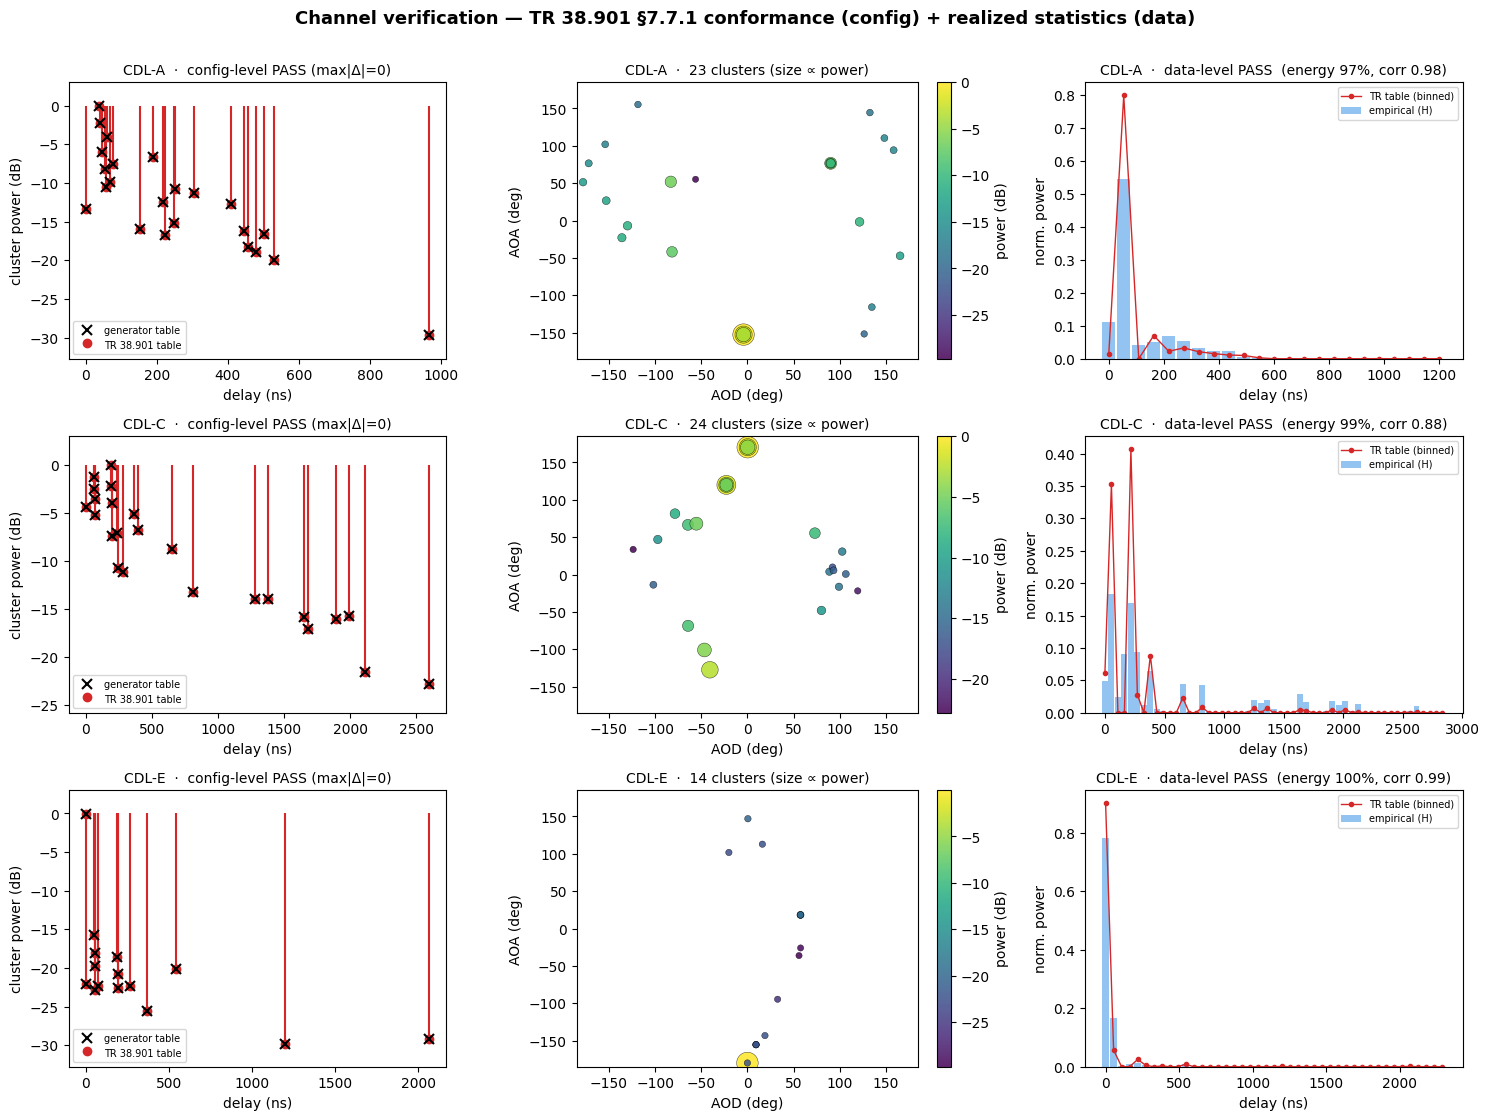

In [6]:
import matplotlib.pyplot as plt

sionna_cfgs = [c for c in CONFIGS if c.data_source == 'sionna']
nrows = len(sionna_cfgs)
fig, axes = plt.subplots(nrows, 3, figsize=(15, 3.7 * nrows), squeeze=False)

for i, cfg in enumerate(sionna_cfgs):
    model = cfg.channel_model
    ref = csi.cdl_reference(model)
    tab = csi.verify_cdl_table(model)
    tau_ns = np.asarray(ref['delays']) * cfg.delay_spread * 1e9     # cluster delays [ns]
    pw_db  = np.asarray(ref['powers'])                             # cluster powers [dB]
    pw_lin = 10 ** (pw_db / 10); pw_lin /= pw_lin.max()
    aod, aoa = np.asarray(ref['aod']), np.asarray(ref['aoa'])

    # --- left: config-level delay-power match (TR table vs generator table) ---
    ax = axes[i][0]
    ax.stem(tau_ns, pw_db, linefmt='C3-', markerfmt='C3o', basefmt=' ', label='TR 38.901 table')
    try:                                                            # overlay the generator's bundled table
        son = csi.verify._load_sionna_table(model)
        ax.plot(np.asarray(son['delays']) * cfg.delay_spread * 1e9, son['powers'],
                'kx', ms=7, mew=1.5, label='generator table')
    except Exception:
        pass
    ax.set(xlabel='delay (ns)', ylabel='cluster power (dB)', ylim=(min(pw_db) - 3, 3))
    ax.set_title(f'{model}  ·  config-level {"PASS" if tab["ok"] else "FAIL"} (max|Δ|=0)', fontsize=10)
    ax.legend(fontsize=7)

    # --- middle: angular cluster map (AOD vs AOA, size ∝ power) ---
    ax = axes[i][1]
    sc = ax.scatter(aod, aoa, s=20 + 220 * pw_lin, c=pw_db, cmap='viridis',
                    alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.set(xlabel='AOD (deg)', ylabel='AOA (deg)', xlim=(-185, 185), ylim=(-185, 185))
    ax.set_title(f'{model}  ·  {ref["num_clusters"]} clusters (size ∝ power)', fontsize=10)
    fig.colorbar(sc, ax=ax, label='power (dB)', fraction=0.046)

    # --- right: data-level empirical vs table PDP ---
    ax = axes[i][2]
    Hte = csi.load_dataset(csi.dataset_dir(cfg))['H_test'][:500]
    gen = csi.verify_generated(Hte, model, delay_spread=cfg.delay_spread, scs=cfg.scs)
    n_sub = Hte.shape[1]; bin_ns = 1e9 / (n_sub * cfg.scs)
    pdp = np.mean(np.abs(np.fft.ifft(Hte, axis=1)) ** 2, axis=(0, 2)); pdp /= pdp.sum()
    theo = np.zeros(n_sub)
    for t, p in zip(tau_ns / bin_ns, pw_lin / pw_lin.sum()):
        theo[int(round(t)) % n_sub] += p
    win = min(n_sub, int(tau_ns.max() / bin_ns) + 6)
    x = np.arange(win) * bin_ns
    ax.bar(x, pdp[:win], width=bin_ns * 0.9, color='#4C9BE8', alpha=0.6, label='empirical (H)')
    ax.plot(x, theo[:win], 'C3o-', ms=3, lw=1, label='TR table (binned)')
    ax.set(xlabel='delay (ns)', ylabel='norm. power')
    ax.set_title(f'{model}  ·  data-level {"PASS" if gen["ok"] else "FAIL"}'
                 f'  (energy {gen["win_energy"]*100:.0f}%, corr {gen["pdp_corr"]:.2f})', fontsize=10)
    ax.legend(fontsize=7)

fig.suptitle('Channel verification — TR 38.901 §7.7.1 conformance (config) + realized statistics (data)',
             y=1.005, fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [7]:
# Reload each dataset and sanity-check shapes/dtypes/keys.
for cfg in CONFIGS:
    ds = csi.load_dataset(csi.dataset_dir(cfg))
    H_tr, H_te, rpt = ds['H_train'], ds['H_test'], ds['reports']
    assert H_tr.dtype == np.complex64 and H_te.dtype == np.complex64
    assert H_tr.shape == (cfg.n_train, cfg.n_sub(), cfg.gnb_tx)
    assert H_te.shape == (cfg.n_test,  cfg.n_sub(), cfg.gnb_tx)
    assert 'W_true' in rpt and 'pmi_sgcs' in rpt
    print(f'  {cfg.to_dirname():16s} train={H_tr.shape} test={H_te.shape} '
          f'sgcs_trunc={float(rpt["sgcs_trunc"]):.4f}  OK')
print('\nAll datasets verified.')


  cdla_3p5ghz      train=(25000, 612, 32) test=(5000, 612, 32) sgcs_trunc=0.9985  OK


  cdlc_3p5ghz      train=(25000, 612, 32) test=(5000, 612, 32) sgcs_trunc=0.9514  OK


  cdle_3p5ghz      train=(25000, 612, 32) test=(5000, 612, 32) sgcs_trunc=0.9999  OK


  mixed_cdl_ace    train=(25000, 612, 32) test=(5000, 612, 32) sgcs_trunc=0.9872  OK


  synthetic_beam   train=(25000, 612, 32) test=(5000, 612, 32) sgcs_trunc=0.9976  OK

All datasets verified.


## Figure — what the generated channel looks like

Two views of one generated CDL channel, to *see* what Stage 1 produced:

- **Left — power-delay profile (PDP):** the empirical PDP recovered from `H` (IDFT
  across subcarriers) with the **TR 38.901 §7.7.1 cluster table** overlaid as stems.
  The generated energy lands on the standard's cluster delays — a visual companion to
  the numeric verification above.
- **Right — beamspace power:** energy per DFT beam (project `H` onto the spatial DFT
  codebook). Shows how angularly spread/sparse the channel is — the structure the PMI
  codebook and the AI encoder must capture.


/var/folders/l5/891cbt2n0m1gmfyh27n91z3m0000gn/T/ipykernel_43631/4025641395.py:18: RuntimeWarning: divide by zero encountered in matmul
  beam = np.mean(np.abs(Hte @ B.conj()) ** 2, axis=(0, 1)); beam /= beam.max()
/var/folders/l5/891cbt2n0m1gmfyh27n91z3m0000gn/T/ipykernel_43631/4025641395.py:18: RuntimeWarning: overflow encountered in matmul
  beam = np.mean(np.abs(Hte @ B.conj()) ** 2, axis=(0, 1)); beam /= beam.max()
/var/folders/l5/891cbt2n0m1gmfyh27n91z3m0000gn/T/ipykernel_43631/4025641395.py:18: RuntimeWarning: invalid value encountered in matmul
  beam = np.mean(np.abs(Hte @ B.conj()) ** 2, axis=(0, 1)); beam /= beam.max()


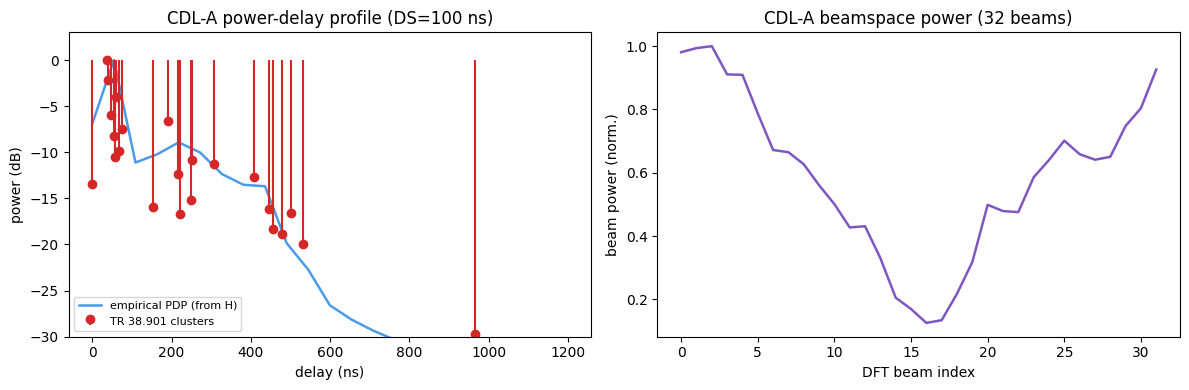

In [8]:
import matplotlib.pyplot as plt

cfg0 = CONFIGS[0]                                   # first config (CDL-A)
ds   = csi.load_dataset(csi.dataset_dir(cfg0))
Hte, cfg = ds['H_test'][:500], ds['cfg']            # a slice is plenty for the figure
n_sub, n_tx = cfg.n_sub(), cfg.gnb_tx

# --- empirical power-delay profile (IDFT across subcarriers) ---
pdp = np.mean(np.abs(np.fft.ifft(Hte, axis=1)) ** 2, axis=(0, 2)); pdp /= pdp.max()
bin_ns = 1e9 / (n_sub * cfg.scs)
taps_ns = np.arange(n_sub) * bin_ns
# --- TR 38.901 cluster delays/powers for this profile ---
ref = csi.cdl_reference(cfg.channel_model)
tau_ns = np.asarray(ref['delays']) * cfg.delay_spread * 1e9
pw = 10 ** (np.asarray(ref['powers']) / 10); pw /= pw.max()
# --- beamspace power: project onto the spatial DFT codebook ---
B = csi.dft_codebook(n_tx, 1)                       # n_tx orthogonal DFT beams
beam = np.mean(np.abs(Hte @ B.conj()) ** 2, axis=(0, 1)); beam /= beam.max()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
win = min(n_sub, int(tau_ns.max() / bin_ns) + 6)
ax[0].plot(taps_ns[:win], 10*np.log10(pdp[:win] + 1e-6), color='#4C9BE8', lw=1.8,
           label='empirical PDP (from H)')
ax[0].stem(tau_ns, 10*np.log10(pw + 1e-6), linefmt='C3-', markerfmt='C3o', basefmt=' ',
           label='TR 38.901 clusters')
ax[0].set(xlabel='delay (ns)', ylabel='power (dB)', ylim=(-30, 3),
          title=f'{cfg.channel_model} power-delay profile (DS={cfg.delay_spread*1e9:.0f} ns)')
ax[0].legend(fontsize=8)
ax[1].plot(np.arange(n_tx), beam, color='#7E57C2', lw=1.8)
ax[1].set(xlabel='DFT beam index', ylabel='beam power (norm.)',
          title=f'{cfg.channel_model} beamspace power ({n_tx} beams)')
plt.tight_layout(); plt.show()


## Per-config directory layout

```
data/<channel_label>/
  train.npz      # H complex64 (n_train, n_sub, n_tx)
  test.npz       # H complex64 (n_test,  n_sub, n_tx)
  reports.npz    # W_true, sgcs_estimation, snr_db, type1/type2 PMI (noisy),
                 # pmi_schemes, pmi_bits, pmi_sgcs, sgcs_trunc, n_delay
  config.json    # ChannelConfig (incl. snr_db, pathloss_db, num_time_steps)
  meta.json      # provenance (channel_model, effective_snr_db, shapes)
```

Downstream notebooks load via `csi.load_dataset(csi.dataset_dir(cfg))`.
